<div style="text-align: center; margin-bottom: 10px;">
  <img src="assets/logo.png" width="200">
</div>

<h1 style="text-align: center;">
Operational Complexity Drivers of Instrument Downtime Risk
</h1>

<h3 style="text-align: center;">
Applied data science case study using simulated QC operational data<br>
Emphasizing interpretability and leakage-aware design
</h3>

<hr style="border: 1px solid #cfd8dc; width: 60%;">

## Data, aggregation, and assumptions

- Data source: simulated QC lab operational data (shared for portfolio use due to NDA constraints), recorded at the run/test level.
- Downtime metadata applies at the instrument-day level; records are aggregated to instrument × day to prevent label leakage.
- Goal: identify operational factors associated with elevated instrument-day downtime risk, prioritizing interpretability over causal claims.
- Target: `is_downtime_day` (1 if the instrument experienced downtime that day, else 0).


## Setup & libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import roc_auc_score

In [2]:
# Reproducibility
RANDOM_STATE = 13579  # fixed seed for all train/test splits and models

## Load Data

In [3]:
# Load run-level operational data (one row per test/run)
df = pd.read_csv("qc_instrument_usage.csv")

print(f'Our data has {df.shape[0]} rows and {df.shape[1]} columns')

# Inspect raw structure
display(df.head())

# Examine downtime events at run-level to illustrate label leakage
# Multiple rows share the same instrument-day downtime label
df[df["downtime_flag"] == 1].sort_values(
    ["instrument_id", "date"]
).head(10)

Our data has 9107 rows and 14 columns


,sample_id,instrument_id,instrument_type,date,test_type,duration_min,turnaround_hours,result,operator,product_family,manual_entry,automation_phase,downtime_flag,downtime_reason
0,S2024-00001,HPLC_01,HPLC,2024-01-01,Assay,35.5,29.5,pass,CF,Reagent_A,0,Before_Automation,0,NaN
1,S2024-00002,HPLC_01,HPLC,2024-01-01,Weigh,38.8,27.8,pass,CF,Reagent_A,0,Before_Automation,0,NaN
2,S2024-00003,HPLC_01,HPLC,2024-01-01,Assay,59.1,31.9,pass,DG,Media_X,0,Before_Automation,0,NaN
3,S2024-00004,HPLC_01,HPLC,2024-01-01,pH Check,31.9,35.9,pass,AD,Reagent_B,1,Before_Automation,0,NaN
4,S2024-00005,HPLC_01,HPLC,2024-01-01,Impurity,57.7,22.9,pass,CF,Media_X,0,Before_Automation,0,NaN


,sample_id,instrument_id,instrument_type,date,test_type,duration_min,turnaround_hours,result,operator,product_family,manual_entry,automation_phase,downtime_flag,downtime_reason
162,S2024-00163,BAL_01,Analytical_Balance,2024-01-09,Impurity,48.5,39.2,pass,AD,Reagent_B,0,Before_Automation,1,calibration
163,S2024-00164,BAL_01,Analytical_Balance,2024-01-09,Endotoxin,29.3,27.9,pass,AD,Media_X,1,Before_Automation,1,calibration
164,S2024-00165,BAL_01,Analytical_Balance,2024-01-09,Assay,31.3,31.3,pass,AD,Media_X,0,Before_Automation,1,calibration
165,S2024-00166,BAL_01,Analytical_Balance,2024-01-09,Assay,54.8,26.3,pass,CF,Media_X,0,Before_Automation,1,calibration
166,S2024-00167,BAL_01,Analytical_Balance,2024-01-09,Impurity,30.7,31.3,pass,CF,Media_Y,0,Before_Automation,1,calibration
864,S2024-00865,BAL_01,Analytical_Balance,2024-02-17,Impurity,45.8,30.0,pass,EL,Media_X,1,Before_Automation,1,software_error
865,S2024-00866,BAL_01,Analytical_Balance,2024-02-17,Weigh,26.2,30.9,pass,AD,Media_Y,1,Before_Automation,1,software_error
3533,S2024-03534,BAL_01,Analytical_Balance,2024-06-01,Impurity,20.8,32.7,pass,CF,Media_Y,0,Before_Automation,1,calibration
3534,S2024-03535,BAL_01,Analytical_Balance,2024-06-01,pH Check,31.9,35.0,pass,AD,Reagent_B,1,Before_Automation,1,calibration
4681,S2024-04682,BAL_01,Analytical_Balance,2024-07-27,pH Check,25.1,22.9,pass,AD,Reagent_A,0,After_Automation,1,maintenance


## Feature Engineering & Aggregation
Downtime labels apply at the instrument-day level; test-level data are aggregated to instrument × day to prevent leakage across runs associated with the same downtime event.

In [4]:
# Normalize to date (drop time-of-day if present)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

def mode1(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return pd.NA
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

agg_map = {
    "instrument_type": ("instrument_type", mode1),

    # Target label at instrument-day level
    "downtime_flag": ("downtime_flag", "max"),

    # Workload / stress
    "n_runs": ("sample_id", "count"),
    "total_duration_min": ("duration_min", "sum"),

    # Workflow / handling
    "pct_manual_entry": ("manual_entry", "mean"),

    # Mix / complexity
    "n_test_types": ("test_type", "nunique"),
    "n_product_families": ("product_family", "nunique"),
    "n_operators": ("operator", "nunique"),
}

df_day = (
    df.groupby(["instrument_id", "date"], as_index=False)
      .agg(**agg_map)
)

df_day["is_downtime_day"] = df_day["downtime_flag"].astype(int)

print("Instrument-days:", df_day.shape)
print(df_day["is_downtime_day"].value_counts(dropna=False))

df_day.head()

Instrument-days: (2047, 11)
is_downtime_day
0    1999
1      48
Name: count, dtype: int64


,instrument_id,date,instrument_type,downtime_flag,n_runs,total_duration_min,pct_manual_entry,n_test_types,n_product_families,n_operators,is_downtime_day
0,BAL_01,2024-01-01,Analytical_Balance,0,5,241.7,0.200,3,3,3,0
1,BAL_01,2024-01-02,Analytical_Balance,0,5,210.9,0.200,4,3,3,0
2,BAL_01,2024-01-03,Analytical_Balance,0,8,378.2,0.625,4,4,3,0
3,BAL_01,2024-01-04,Analytical_Balance,0,8,333.5,0.250,4,3,5,0
4,BAL_01,2024-01-05,Analytical_Balance,0,4,162.0,0.000,4,3,4,0


## Exploratory Analysis
Examine differences in workload, workflow complexity, and handling patterns between downtime and non-downtime instrument-days.

### Baseline Risk by Instrument Type
Instrument type is treated as a baseline control to contextualize downtime risk, not as a primary driver for intervention.

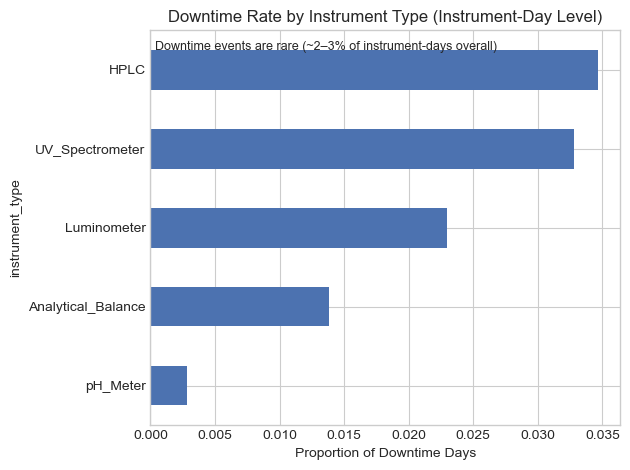

In [5]:
# # Instrument type is associated with baseline downtime risk (contextual control)
instrument_downtime_rate = (
    df_day
    .groupby("instrument_type")["is_downtime_day"]
    .mean()
    .sort_values(ascending=True)
)
instrument_downtime_rate

instrument_downtime_rate.plot(kind="barh", color="#4C72B0")
plt.title("Downtime Rate by Instrument Type (Instrument-Day Level)")
plt.xlabel("Proportion of Downtime Days")
plt.annotate(
    "Downtime events are rare (~2–3% of instrument-days overall)",
    xy=(0.01, 0.95),
    xycoords="axes fraction",
    fontsize=9
)
plt.tight_layout()
plt.show()

### Numeric Signals Associated with Downtime Risk
Compare upstream workload and complexity metrics between downtime and non-downtime instrument-days.

In [6]:
num_features = [
    "n_runs",               # workload / stress
    "pct_manual_entry",     # handling complexity
    "n_test_types",         # assay heterogeneity
    "n_product_families",   # material diversity
    "n_operators"           # human coordination
]

grp = df_day[num_features + ["is_downtime_day"]].groupby("is_downtime_day")

grp.median().T
grp.quantile([0.25, 0.75])
grp.median().T.rename(columns={0: "No downtime", 1: "Downtime"})

is_downtime_day,No downtime,Downtime
n_runs,4.000000,3.000
pct_manual_entry,0.166667,0.125
n_test_types,3.000000,2.500
n_product_families,3.000000,2.000
n_operators,3.000000,2.000


Median comparisons suggest that downtime risk is driven by extreme or atypical conditions rather than typical instrument-days, motivating distributional and threshold-based analysis.

### EDA Summary
- Downtime rates vary by instrument type, with HPLC and UV spectrometers exhibiting a higher proportion of downtime days. This reflects baseline differences in operational complexity across instrument types.
- Downtime events are rare (~2–3% of instrument-days). Median comparisons indicate that downtime is driven by atypical or high-complexity conditions rather than typical instrument-day behavior.
- These patterns motivate modeling downtime as a risk event associated with operational conditions, rather than a per-run prediction task.

## Baseline Model: Instrument-Day Downtime Risk
Given the rarity of downtime events, model performance is evaluated using ROC-AUC, as accuracy is not informative for rare events.

In [7]:
# Target
y = df_day["is_downtime_day"].astype(int)

# Features (actionable, upstream)
X = df_day[num_features].copy()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

In [9]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

In [10]:
model.fit(X_train, y_train)

# Predicted probabilities (for ROC-AUC)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("Logistic Regression — ROC-AUC:",
      roc_auc_score(y_test, y_proba))

Logistic Regression — ROC-AUC: 0.4770620394580461


Linear models show no meaningful ranking ability, motivating exploration of nonlinear, threshold-based risk regimes.

In [11]:
tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)

y_proba = tree.predict_proba(X_test)[:, 1]
y_pred = tree.predict(X_test)

print("Shallow Decision Tree — ROC-AUC:",
      roc_auc_score(y_test, y_proba))

print("\nDecision rules:\n")
print(export_text(tree, feature_names=list(X.columns)))

Shallow Decision Tree — ROC-AUC: 0.5473021155217495

Decision rules:

|--- n_test_types <= 4.50
|   |--- n_operators <= 4.50
|   |   |--- pct_manual_entry <= 0.54
|   |   |   |--- class: 1
|   |   |--- pct_manual_entry >  0.54
|   |   |   |--- class: 1
|   |--- n_operators >  4.50
|   |   |--- class: 0
|--- n_test_types >  4.50
|   |--- class: 0



### Model Interpretation: Operational Risk Regimes

To interpret downtime risk, we examine threshold-based patterns identified by a shallow decision tree that highlights discrete operational regimes associated with elevated risk.

## Conclusions & Implications
Downtime does not emerge from typical workload variation. Instead, events cluster within high-complexity operational regimes.

A shallow decision tree reveals risk conditions defined by thresholds in test mix, operator involvement, and manual handling. This indicates that downtime is associated with complexity accumulation and coordination strain rather than raw workload volume.

Practically, this supports shifting from average performance monitoring to regime detection and complexity-aware scheduling.

## Limitations & Next Steps

**Limitations**
- Data are simulated; effect sizes are illustrative.
- Findings reflect association, not causation.
- Downtime is rare; accuracy is not an appropriate evaluation metric.

**Next Steps**
- Validate findings using real historical instrument logs.
- Incorporate time-aware risk features (lagged workload, rolling windows).
- Segment downtime by category (maintenance, software, calibration).
- Quantify operational impact of identified risk regimes.